Оцінювання наявності даної роботи буде враховувати як наявність самих візуалізацій (вони можуть незначно відрізнятися від прикладів, але повинні змістовно відображати суть задачі) та опис отриманих вами результатів. При наявності ЛИШЕ візуалізацій без роз'яснень, завдання не буде зараховане за наявне.

Під час виконання вам дозволено користуватися будь-якими зручними для вас Python бібліотеками для візуалізації.

# I. Receiving Data.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

1. (2б) Для виконання цієї лабораторної роботи Вам необхідно скористатися вибіркою titanic ([train.csv](https://www.kaggle.com/c/titanic/data?select=train.csv)). Зчитайте його та збережіть його у змінну, щоб у подальшому її використати для візуалізацій. Виведіть інформацію про кожну колонку, її індекс, тип та кількість непропущених значень та перші кілька рядків датафрейму.


In [27]:
df = pd.read_csv("train.csv")

In [28]:
print("Інформація про датафрейм:")
print(df.info())

print("\nПерші 5 рядків датафрейму:")
print(df.head(5))

Інформація про датафрейм:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Перші 5 рядків датафрейму:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4    

# IІ. Data Visualization.

2. (10б) Створіть pie chart, який би показував співвідношення виживших до загиблих.

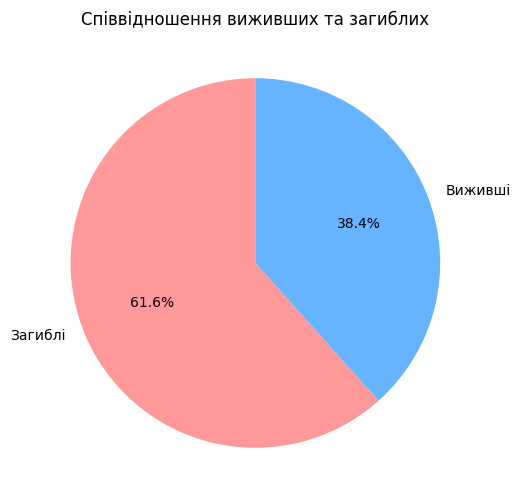

In [29]:
survival_counts = df['Survived'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(
    survival_counts,
    labels=['Загиблі', 'Виживші'],
    autopct='%1.1f%%',
    startangle=90,
    colors = ['#ff9999', '#66b3ff']
)
plt.title('Співвідношення виживших та загиблих')
plt.show()

На графіку видно, що більшість пасажирів загинули. Сектор “Загиблі” займає більшу частину кола, тоді як сектор “Виживші” менший. Використання різних кольорів (червоний для загиблих, блакитний для виживших) допомагає одразу зрозуміти, який сектор за що відповідає.
Відсотки всередині секторів (autopct='%1.1f%%') дозволяють швидко оцінити пропорції без підрахунку чисел вручну.

3. (20б) Створіть bar chart, який би показував співвідношення загиблих до виживших для кожної статі. Для groupby використовуйте атрибут as_index=False.


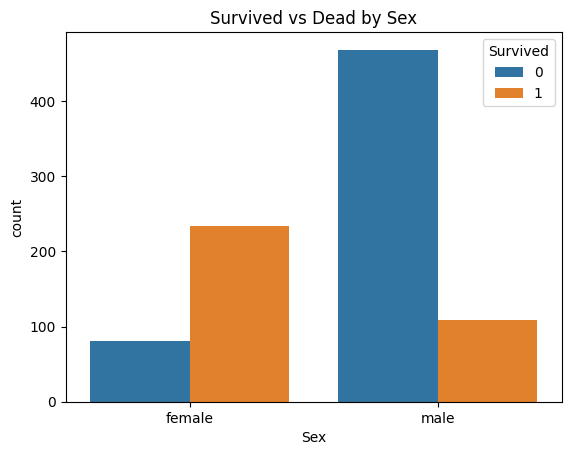

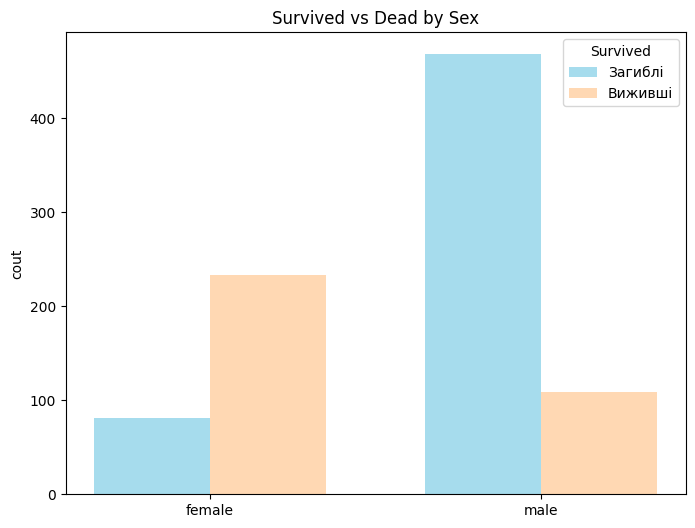

In [30]:
grouped = df.groupby(['Sex', 'Survived'], as_index=False).size()
grouped.rename(columns={'size': 'Count'}, inplace=True)

female_dead = grouped[(grouped['Sex'] == 'female') & (grouped['Survived'] == 0)]['Count'].values[0]
female_alive = grouped[(grouped['Sex'] == 'female') & (grouped['Survived'] == 1)]['Count'].values[0]
male_dead = grouped[(grouped['Sex'] == 'male') & (grouped['Survived'] == 0)]['Count'].values[0]
male_alive = grouped[(grouped['Sex'] == 'male') & (grouped['Survived'] == 1)]['Count'].values[0]


x = np.arange(2)
width = 0.35

plt.figure(figsize=(8,6))
plt.bar(x - width/2, [female_dead, male_dead], width, label='Загиблі', color='#a6dced')
plt.bar(x + width/2, [female_alive, male_alive], width, label='Виживші', color='#ffd8b3')

plt.xticks(x, ['female', 'male'])
plt.ylabel('cout')
plt.title('Survived vs Dead by Sex')
plt.legend(title='Survived')
plt.show()

Для жінок більшість пасажирів вижили (помаранчевий бар вище за блакитний).
Для чоловіків більшість пасажирів загинули (блакитний бар значно вище за помаранчевий).

Різні кольори барів допомагають легко порівняти величини.
Бар-чарт групований по статі, що дозволяє одразу бачити дисбаланс між чоловіками та жінками.

4. (20б) Відобразіть кількість пропущених значень в датасеті по кожній із змінних.

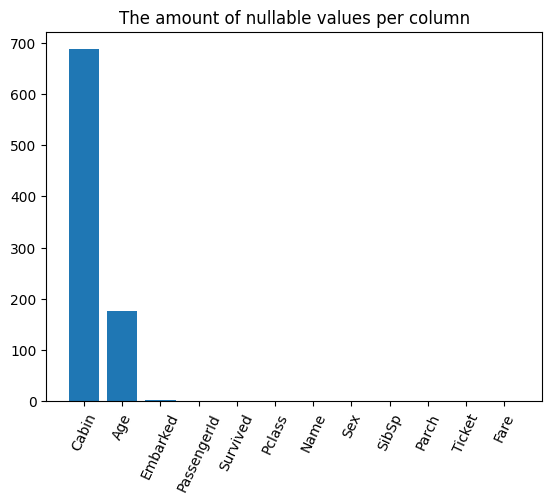

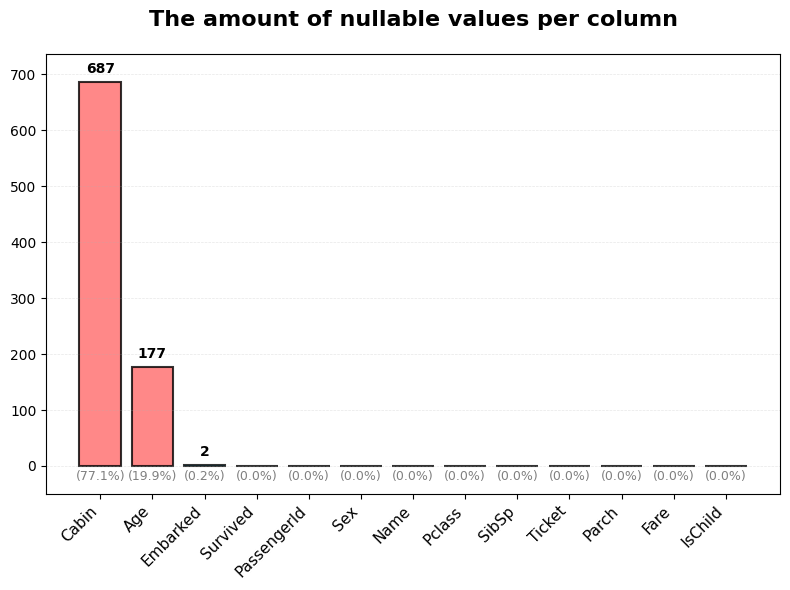

In [44]:
missing_counts = df.isnull().sum()

missing_counts = missing_counts.sort_values(ascending=False)

plt.figure(figsize=(8, 6))

bars = plt.bar(missing_counts.index, missing_counts.values,
               color=['#FF6B6B' if x > 100 else '#4ECDC4' if x > 10 else '#45B7D1' for x in missing_counts.values],
               edgecolor='black',
               linewidth=1.5,
               alpha=0.8)

for bar in bars:
    height = bar.get_height()
    if height > 0:
        plt.text(bar.get_x() + bar.get_width()/2., height + 10,
                f'{int(height)}',
                ha='center',
                va='bottom',
                fontsize=10,
                fontweight='bold')

for i, (col, val) in enumerate(missing_counts.items()):
    percent = (val / len(df)) * 100
    plt.text(i, -25,
             f'({percent:.1f}%)',
             ha='center',
             fontsize=9,
             color='gray')

plt.title('The amount of nullable values per column',
          fontsize=16,
          fontweight='bold',
          pad=20)
plt.xticks(range(len(missing_counts.index)), missing_counts.index, rotation=45, ha='right', fontsize=11)
plt.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.5)

plt.ylim(-50, max(missing_counts.values) + 50)

plt.tight_layout()
plt.show()


На графіку чітко видно, що найбільша кількість пропущених значень припадає на колонку Cabin — вона має значну кількість пропусків. Це означає, що ця змінна є найменш заповненою в датасеті.Другою за кількістю пропущених значень є колонка Age — приблизно 20% даних відсутні. Це важлива змінна, тому її пропуски потребують обробки.Колонка Embarked має дуже незначну кількість пропущених значень.
Більшість інших колонок (PassengerId, Survived, Pclass, Name, Sex, SibSp, Parch, Ticket, Fare) не містять пропусків.

5. (10б) Побудуйте наступний графік, дайте йому назву та опишіть, що власне на них відображається.

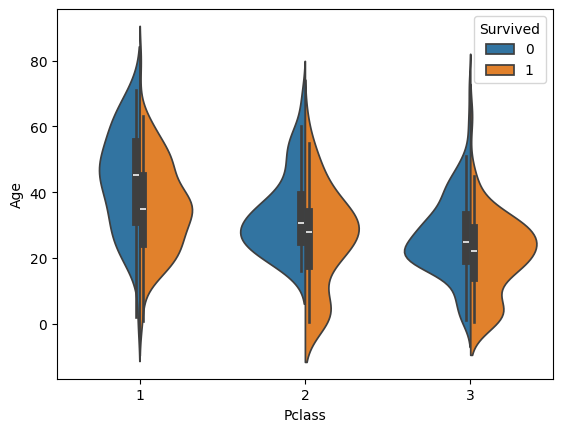

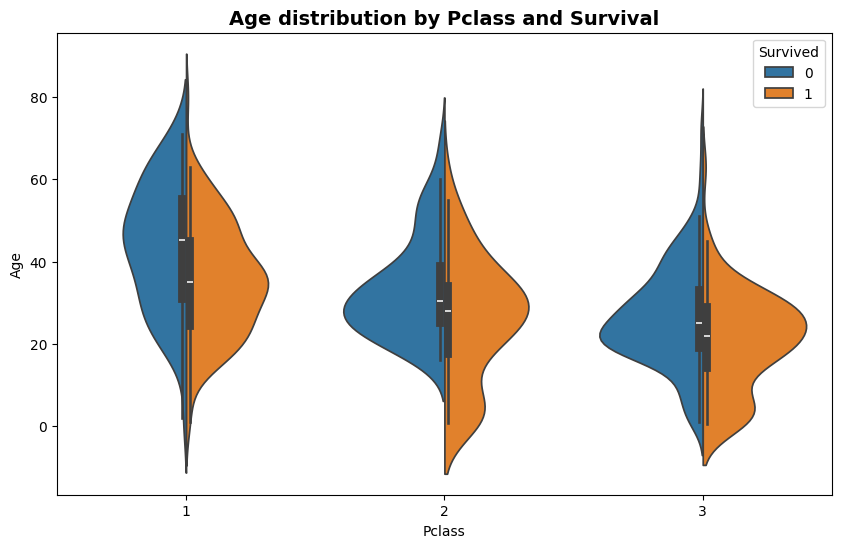

In [32]:
df_age = df.dropna(subset=['Age'])

plt.figure(figsize=(10,6))

sns.violinplot(
    data=df_age,
    x='Pclass',
    y='Age',
    hue='Survived',
    split=True,
    inner='box'
)

plt.title('Age distribution by Pclass and Survival', fontsize=14, fontweight='bold')
plt.xlabel('Pclass')
plt.ylabel('Age')
plt.legend(title='Survived')

plt.show()

Даний графік (violin plot) відображає розподіл віку пасажирів залежно від класу каюти (Pclass) та факту виживання (Survived). Для кожного класу показано, як розподіляється вік серед загиблих і виживших, що дозволяє порівняти не лише середні значення, а й форму розподілу. Можна помітити, що в першому класі пасажири загалом були старшими, і серед них частка виживших є більшою порівняно з іншими класами. У другому класі розподіл віку більш рівномірний, проте також спостерігається певна перевага виживших серед молодших пасажирів. У третьому класі переважають молодші люди, однак саме тут найбільше загиблих, що свідчить про нижчі шанси на виживання.

6. (13б) Побудуйте графік розподілу частот по віку пасажирів.


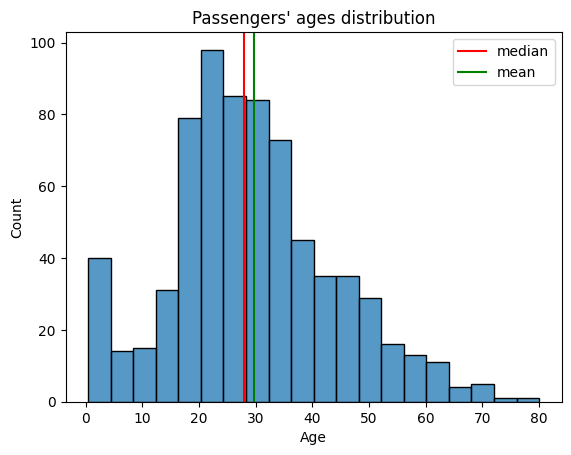

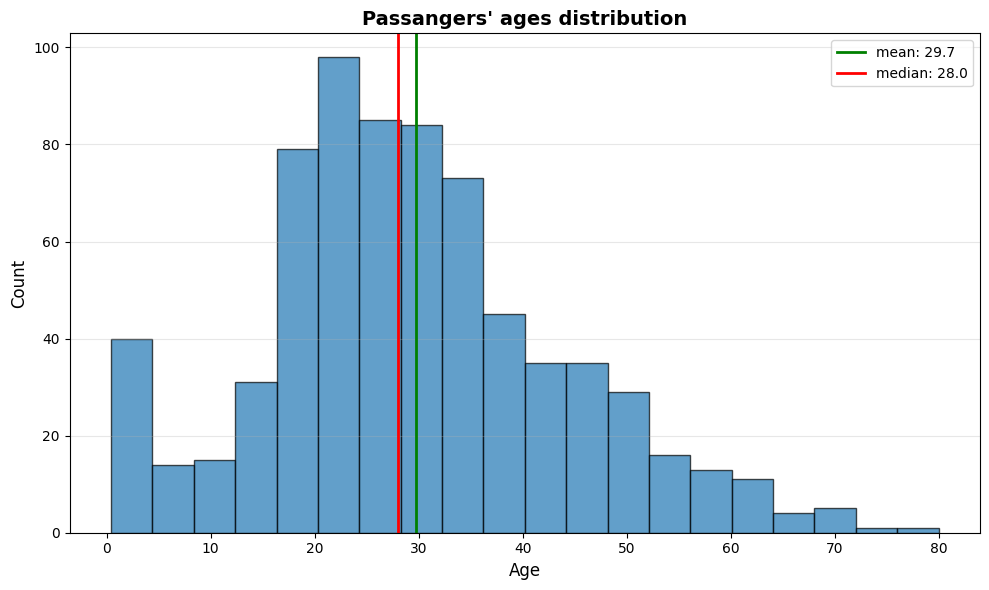

In [33]:
age = df['Age'].dropna()

plt.figure(figsize=(10, 6))

plt.hist(age, bins=20, color='#1f77b4', edgecolor='black', alpha=0.7)

plt.axvline(age.mean(), color='green', linewidth=2,
            label=f'mean: {age.mean():.1f}')
plt.axvline(age.median(), color='red', linewidth=2,
            label=f'median: {age.median():.1f}')

plt.title("Passangers' ages distribution", fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Гістограма розподілу віку пасажирів показує, що найбільшу частину становлять люди віком приблизно від 20 до 40 років, тобто переважають пасажири молодого та середнього віку. Розподіл є асиметричним із правим хвостом, що свідчить про наявність меншої кількості старших пасажирів (50+ років), які впливають на загальну форму графіка. Це також підтверджується тим, що середнє значення віку є дещо більшим за медіану. Крім того, на графіку видно наявність дітей, однак їх частка є значно меншою порівняно з дорослими пасажирами. Отже, можна зробити висновок, що основну масу пасажирів складали люди молодого та середнього віку, а розподіл віку є нерівномірним, що варто враховувати при подальшому аналізі даних.

7. (25б) Поставте бізнес-питання до даних. Дайте на нього відповідь за допомогою візуалізацій. Прокоментуйте отриману відповідь.

Чи залежить виживання від порту посадки (Embarked)?

Чи мали діти більший шанс вижити?

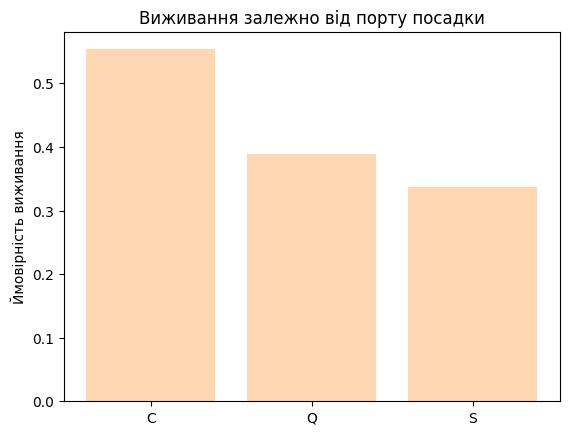

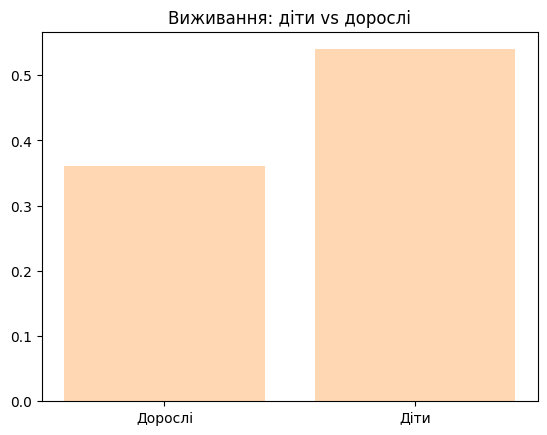

In [40]:
#Чи залежить виживання від порту посадки (Embarked)?
survival_embarked = df.groupby('Embarked')['Survived'].mean()

plt.bar(survival_embarked.index, survival_embarked.values, color='#ffd8b3')
plt.title('Виживання залежно від порту посадки')
plt.ylabel('Ймовірність виживання')
plt.show()

#Чи мали діти більший шанс вижити?
df['IsChild'] = df['Age'] < 18

survival_child = df.groupby('IsChild')['Survived'].mean()

plt.bar(['Дорослі', 'Діти'], survival_child.values, color='#ffd8b3')
plt.title('Виживання: діти vs дорослі')
plt.show()

Побудовані візуалізації показують, що ймовірність виживання частково залежала від порту посадки пасажирів. Можна спостерігати певні відмінності між категоріями Embarked, однак вони не є настільки значними, як у випадку зі статтю чи класом каюти. Це може свідчити про те, що порт посадки опосередковано пов’язаний із соціальним статусом пасажирів або іншими факторами, але сам по собі не є вирішальним чинником виживання.

Щодо віку, графік демонструє, що діти мали вищу ймовірність вижити порівняно з дорослими пасажирами.

# Вітаю! Ви велика(ий) молодець, що впоралась(вся). Похваліть себе та побалуйте чимось приємним. Я Вами пишаюся.

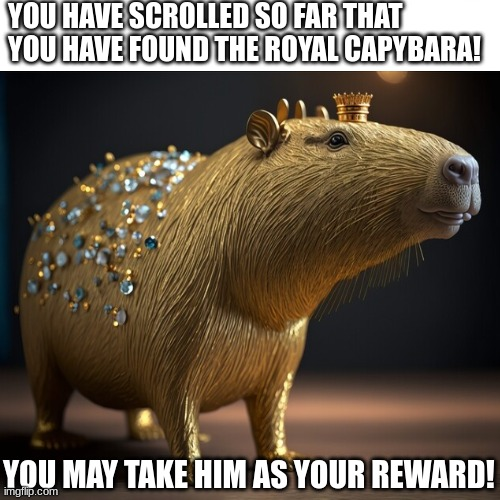